#  Projeto 2: Motor Temporal, Calibração e Otimização Quantitativa
Neste laboratório, vamos eliminar o *Data Leakage* construindo um motor de séries temporais para calcular médias móveis de xG e xGA (Ataque e Defesa). Em seguida, treinaremos um *Random Forest*, calibraremos suas probabilidades e criaremos um Radar de Valor Esperado (EV+) para encontrar o ponto de lucro máximo contra as *Odds* da Bet365.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

print("1. EXTRAÇÃO E LIMPEZA (Match Logs)")
url_calendario = "https://web.archive.org/web/20240525141014/https://fbref.com/en/comps/9/2023-2024/schedule/2023-2024-Premier-League-Scores-and-Fixtures"
df_cronologico = pd.read_html(url_calendario, match="Wk")[0]

df_limpo = df_cronologico.dropna(subset=['Wk']).copy()
df_limpo = df_limpo[['Wk', 'Date', 'Home', 'xG', 'Score', 'xG.1', 'Away']].rename(columns={'Wk': 'Rodada', 'Date': 'Data', 'Home': 'Mandante', 'xG': 'xG_Mandante', 'Score': 'Placar', 'xG.1': 'xG_Visitante', 'Away': 'Visitante'}).reset_index(drop=True)

df_limpo['xG_Mandante'] = pd.to_numeric(df_limpo['xG_Mandante'], errors='coerce')
df_limpo['xG_Visitante'] = pd.to_numeric(df_limpo['xG_Visitante'], errors='coerce')
df_historico = df_limpo.dropna(subset=['xG_Mandante', 'xG_Visitante']).copy()

df_historico[['Gols_Mandante', 'Gols_Visitante']] = df_historico['Placar'].str.extract(r'(\d+)[^\d]+(\d+)')
df_historico['Gols_Mandante'] = pd.to_numeric(df_historico['Gols_Mandante'])
df_historico['Gols_Visitante'] = pd.to_numeric(df_historico['Gols_Visitante'])
print("Base limpa extraída com sucesso.")

1. EXTRAÇÃO E LIMPEZA (Match Logs)
Base limpa extraída com sucesso.


In [3]:
print("2. MOTOR TEMPORAL (Calculando Ataque e Defesa sem Data Leakage)")

times = pd.concat([df_historico['Mandante'], df_historico['Visitante']]).unique()
mochila_xg = {time: [] for time in times} 
mochila_xga = {time: [] for time in times} 

m_xg_man, m_xga_man, m_xg_vis, m_xga_vis = [], [], [], []

for index, jogo in df_historico.iterrows():
    man, vis = jogo['Mandante'], jogo['Visitante']
    
    m_xg_man.append(np.mean(mochila_xg[man][-5:]) if len(mochila_xg[man]) > 0 else 0)
    m_xga_man.append(np.mean(mochila_xga[man][-5:]) if len(mochila_xga[man]) > 0 else 0)
    m_xg_vis.append(np.mean(mochila_xg[vis][-5:]) if len(mochila_xg[vis]) > 0 else 0)
    m_xga_vis.append(np.mean(mochila_xga[vis][-5:]) if len(mochila_xga[vis]) > 0 else 0)
    
    mochila_xg[man].append(jogo['xG_Mandante'])
    mochila_xga[man].append(jogo['xG_Visitante']) 
    mochila_xg[vis].append(jogo['xG_Visitante'])
    mochila_xga[vis].append(jogo['xG_Mandante']) 

df_historico['Casa_xG_Ataque'] = np.round(m_xg_man, 2)
df_historico['Casa_xGA_Defesa'] = np.round(m_xga_man, 2)
df_historico['Fora_xG_Ataque'] = np.round(m_xg_vis, 2)
df_historico['Fora_xGA_Defesa'] = np.round(m_xga_vis, 2)

df_historico['Total_Gols'] = df_historico['Gols_Mandante'] + df_historico['Gols_Visitante']
df_historico['Target_Over25'] = np.where(df_historico['Total_Gols'] > 2.5, 1, 0)
print("Feature Engineering Temporal concluída.")

2. MOTOR TEMPORAL (Calculando Ataque e Defesa sem Data Leakage)
Feature Engineering Temporal concluída.


In [4]:
print("3. MERGE, MACHINE LEARNING E CALIBRAÇÃO")

df_odds = pd.read_csv("https://www.football-data.co.uk/mmz4281/2324/E0.csv")[['HomeTeam', 'AwayTeam', 'B365>2.5', 'B365<2.5']]
dicionario = {'Luton Town': 'Luton', 'Manchester City': 'Man City', 'Manchester Utd': 'Man United', 'Newcastle Utd': 'Newcastle', "Nott'ham Forest": "Nott'm Forest", 'Sheffield Utd': 'Sheffield United'}
df_historico['Mandante_Odds'] = df_historico['Mandante'].replace(dicionario)
df_historico['Visitante_Odds'] = df_historico['Visitante'].replace(dicionario)
df_bt = pd.merge(df_historico, df_odds, left_on=['Mandante_Odds', 'Visitante_Odds'], right_on=['HomeTeam', 'AwayTeam'], how='inner')

features = ['Casa_xG_Ataque', 'Casa_xGA_Defesa', 'Fora_xG_Ataque', 'Fora_xGA_Defesa']
X_train, X_test, y_train, y_test = train_test_split(df_bt[features], df_bt['Target_Over25'], test_size=0.20, shuffle=False)

# Treinamento e Calibração (Lente Corretiva)
rf = RandomForestClassifier(n_estimators=150, random_state=42, max_depth=5)
modelo_calibrado = CalibratedClassifierCV(estimator=rf, method='sigmoid', cv=5).fit(X_train, y_train)

df_teste = df_bt.iloc[X_test.index].copy()
probs = modelo_calibrado.predict_proba(X_test)
df_teste['Prob_Under'], df_teste['Prob_Over'] = probs[:, 0], probs[:, 1]
print("Modelo treinado e probabilidades calibradas para finanças.")

3. MERGE, MACHINE LEARNING E CALIBRAÇÃO
Modelo treinado e probabilidades calibradas para finanças.


4. RADAR QUANTITATIVO (Buscando o EV+ Perfeito)


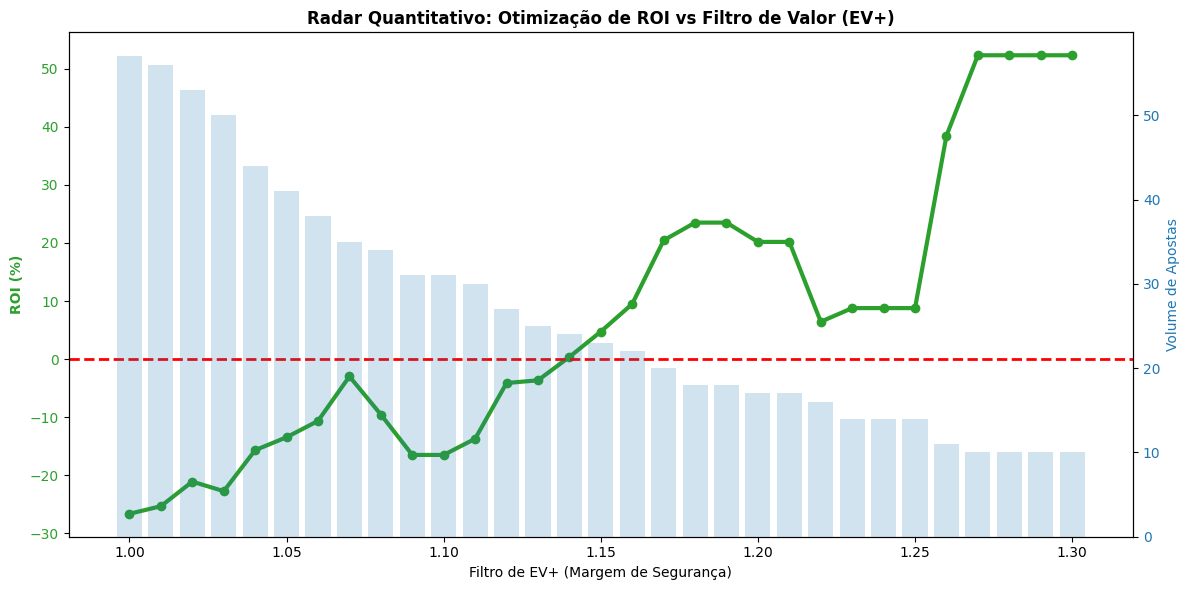

Melhor Filtro EV+ é 1.27
ROI Máximo Possível: 52.30% | Entradas: 10


In [5]:
print("4. RADAR QUANTITATIVO (Buscando o EV+ Perfeito)")

thresholds = np.arange(1.00, 1.30, 0.01)
resultados_roi, apostas_totais = [], []

for thresh in thresholds:
    banca_temp, apostas_temp = 1000.00, 0
    for _, jogo in df_teste.iterrows():
        ev_over = jogo['Prob_Over'] * jogo['B365>2.5']
        ev_under = jogo['Prob_Under'] * jogo['B365<2.5']
        
        if ev_over > thresh:
            apostas_temp += 1
            banca_temp += 10.00 * (jogo['B365>2.5'] - 1) if jogo['Target_Over25'] == 1 else -10.00
        elif ev_under > thresh:
            apostas_temp += 1
            banca_temp += 10.00 * (jogo['B365<2.5'] - 1) if jogo['Target_Over25'] == 0 else -10.00
                
    resultados_roi.append(((banca_temp - 1000.00) / (apostas_temp * 10.00)) * 100 if apostas_temp > 0 else 0)
    apostas_totais.append(apostas_temp)

# Veredito Visual do Radar
fig, ax1 = plt.subplots(figsize=(12, 6))
color = 'tab:green'
ax1.set_xlabel('Filtro de EV+ (Margem de Segurança)')
ax1.set_ylabel('ROI (%)', color=color, fontweight='bold')
ax1.plot(thresholds, resultados_roi, color=color, linewidth=3, marker='o')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero (Empate)')

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Volume de Apostas', color=color)  
ax2.bar(thresholds, apostas_totais, color=color, alpha=0.2, width=0.008)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Radar Quantitativo: Otimização de ROI vs Filtro de Valor (EV+)', fontweight='bold')
fig.tight_layout(); plt.show()

melhor_roi = max(resultados_roi)
melhor_thresh = thresholds[resultados_roi.index(melhor_roi)]
print(f"Melhor Filtro EV+ é {melhor_thresh:.2f}")
print(f"ROI Máximo Possível: {melhor_roi:.2f}% | Entradas: {apostas_totais[resultados_roi.index(melhor_roi)]}")